# Intro to TSFresh: automated feature engineering for grouped time series data (inspired by physics)
-----------------------
**Dr. Dave Wanik - Operations and Information Management - University of Connecticut**

References:
* [TSFresh Homepage](https://tsfresh.readthedocs.io/en/latest/)
* [Overview of calculated features](https://tsfresh.readthedocs.io/en/latest/text/list_of_features.html)
* [Robot failures quick start example](https://tsfresh.readthedocs.io/en/latest/text/quick_start.html)

## Download the data

In [1]:
# https://drive.google.com/file/d/1OSfwPy5EvIDbslnQwoVCC8irWs3pgwmD/view?usp=sharing
!gdown 1OSfwPy5EvIDbslnQwoVCC8irWs3pgwmD

Downloading...
From: https://drive.google.com/uc?id=1OSfwPy5EvIDbslnQwoVCC8irWs3pgwmD
To: /content/BDL_FiveYears.csv
100% 17.6M/17.6M [00:00<00:00, 68.4MB/s]


## Data Dictionary

| Variable | Description |
| :--- | :--- |
| `station` | Three or four character site identifier |
| `valid` | Timestamp of the observation |
| `tmpf` | Air Temperature in Fahrenheit, typically @ 2 meters |
| `dwpf` | Dew Point Temperature in Fahrenheit, typically @ 2 meters |
| `relh` | Relative Humidity in % |
| `drct` | Wind Direction in degrees from *true* north |
| `sknt` | Wind Speed in knots |
| `p01i` | One hour precipitation for the period from the observation time to the time of the previous hourly precipitation reset. Values are in inches. *Note: This varies slightly by site and may contain melted frozen precipitation.* |
| `alti` | Pressure altimeter in inches |
| `mslp` | Sea Level Pressure in millibar |
| `vsby` | Visibility in miles |
| `gust` | Wind Gust in knots |
| `skyc1` - `skyc4` | Sky Coverage Levels 1 through 4 |
| `skyl1` - `skyl4` | Sky Altitude Levels 1 through 4 (in feet) |
| `wxcodes` | Present Weather Codes (space separated) |
| `feel` | Apparent Temperature (Wind Chill or Heat Index) in Fahrenheit |
| `ice_accretion_1hr` | Ice Accretion over 1 Hour (inches) |
| `ice_accretion_3hr` | Ice Accretion over 3 Hours (inches) |
| `ice_accretion_6hr` | Ice Accretion over 6 Hours (inches) |
| `peak_wind_gust` | Peak Wind Gust (knots) — *from PK WND METAR remark* |
| `peak_wind_drct` | Peak Wind Gust Direction (deg) — *from PK WND METAR remark* |
| `peak_wind_time` | Peak Wind Gust Time — *from PK WND METAR remark* |
| `metar` | Unprocessed reported observation in METAR format |

In [2]:
# make sure tsfresh is installed
!pip install tsfresh
import tsfresh

In [3]:
# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# read some data
df = pd.read_csv('BDL_FiveYears.csv')
df.head()

,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,vsby
0,BDL,1/1/2015 0:51,17.96,6.08,59.10,190.0,5.0,0.0,30.09,1019.0,10.0
1,BDL,1/1/2015 1:51,19.94,8.06,59.40,190.0,5.0,0.0,30.08,1018.7,10.0
2,BDL,1/1/2015 2:51,23.00,6.98,49.69,210.0,9.0,0.0,30.06,1018.1,10.0
3,BDL,1/1/2015 3:51,21.92,5.00,47.52,230.0,11.0,0.0,30.04,1017.4,10.0
4,BDL,1/1/2015 4:51,23.00,3.92,43.21,250.0,13.0,0.0,30.05,1017.7,10.0


In [5]:
# check data types
df.dtypes

,0
station,object
valid,object
tmpf,float64
dwpf,float64
relh,float64
drct,float64
sknt,float64
p01i,float64
alti,float64
mslp,float64


In [6]:
# convert valid to datetime
# for easy wrangling
df['valid'] = pd.to_datetime(df['valid'])
df.dtypes

,0
station,object
valid,datetime64[ns]
tmpf,float64
dwpf,float64
relh,float64
drct,float64
sknt,float64
p01i,float64
alti,float64
mslp,float64


## Resample to consistent temporal resolution (hourly)

In [7]:
df.index = df['valid']
# Drop the 'station' column before resampling, as it's non-numeric
tmp = df.drop(columns=['station']).resample('60min').mean()
tmp.head() # looks good! character columns dropped automatically

,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,vsby
valid,,,,,,,,,,
2015-01-01 00:00:00,2015-01-01 00:51:00,17.96,6.08,59.10,190.0,5.0,0.0,30.09,1019.0,10.0
2015-01-01 01:00:00,2015-01-01 01:51:00,19.94,8.06,59.40,190.0,5.0,0.0,30.08,1018.7,10.0
2015-01-01 02:00:00,2015-01-01 02:51:00,23.00,6.98,49.69,210.0,9.0,0.0,30.06,1018.1,10.0
2015-01-01 03:00:00,2015-01-01 03:51:00,21.92,5.00,47.52,230.0,11.0,0.0,30.04,1017.4,10.0
2015-01-01 04:00:00,2015-01-01 04:51:00,23.00,3.92,43.21,250.0,13.0,0.0,30.05,1017.7,10.0


In [8]:
# let's create a new column for date
tmp['Date'] = tmp.index
tmp['Date'] = tmp['Date'].dt.strftime('%m/%d/%Y')
tmp['Date'] = pd.to_datetime(tmp['Date'])
print(tmp.dtypes)
tmp.head()

valid    datetime64[ns]
tmpf            float64
dwpf            float64
relh            float64
drct            float64
sknt            float64
p01i            float64
alti            float64
mslp            float64
vsby            float64
Date     datetime64[ns]
dtype: object


,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,vsby,Date
valid,,,,,,,,,,,
2015-01-01 00:00:00,2015-01-01 00:51:00,17.96,6.08,59.10,190.0,5.0,0.0,30.09,1019.0,10.0,2015-01-01
2015-01-01 01:00:00,2015-01-01 01:51:00,19.94,8.06,59.40,190.0,5.0,0.0,30.08,1018.7,10.0,2015-01-01
2015-01-01 02:00:00,2015-01-01 02:51:00,23.00,6.98,49.69,210.0,9.0,0.0,30.06,1018.1,10.0,2015-01-01
2015-01-01 03:00:00,2015-01-01 03:51:00,21.92,5.00,47.52,230.0,11.0,0.0,30.04,1017.4,10.0,2015-01-01
2015-01-01 04:00:00,2015-01-01 04:51:00,23.00,3.92,43.21,250.0,13.0,0.0,30.05,1017.7,10.0,2015-01-01


In [9]:
# the date is looking pretty good!
# we are going to treat the day as the binning variable
# we can attach ANY target variable to these data!
# so long as it's at daily resolution...

# let's see if we can predict the daily max
# of dwpf, and use the other variables to
# predict it

# Define target variable (y): Max(dew point) per day
Since our grouping variable is daily resolution, so should our target variable.

In [10]:
# make a new table
Y = tmp.groupby(['Date'], sort=False)['dwpf'].max()
Y.head()

,dwpf
Date,
2015-01-01,14.00
2015-01-02,23.00
2015-01-03,26.96
2015-01-04,38.48
2015-01-05,35.06


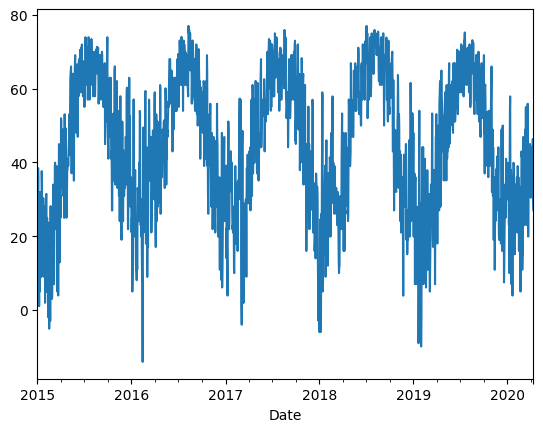

In [11]:
# see the temporal nature - nice plot with pandas
Y.plot()
plt.show()

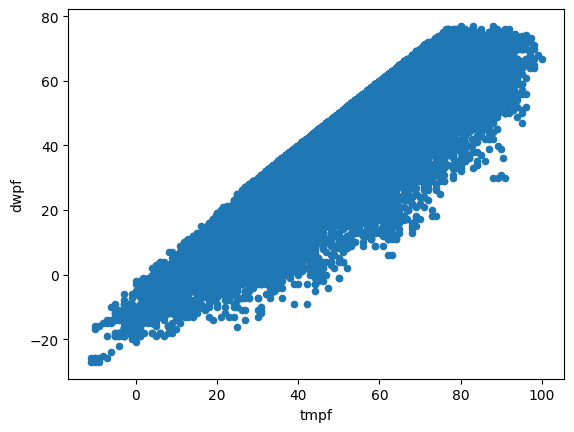

In [12]:
# check out x=tmpf vs. y=dwpf
tmp.plot.scatter(x='tmpf', y='dwpf')
plt.show()

# TSFresh!

In [13]:
# first, let's drop the dwpf and valid columns
tmp = tmp.drop(['dwpf', 'valid'], axis=1)

In [14]:
# add the time from index INTO the dataframe as our time step variable
tmp['MyTime'] = tmp.index
tmp.head()

,tmpf,relh,drct,sknt,p01i,alti,mslp,vsby,Date,MyTime
valid,,,,,,,,,,
2015-01-01 00:00:00,17.96,59.10,190.0,5.0,0.0,30.09,1019.0,10.0,2015-01-01,2015-01-01 00:00:00
2015-01-01 01:00:00,19.94,59.40,190.0,5.0,0.0,30.08,1018.7,10.0,2015-01-01,2015-01-01 01:00:00
2015-01-01 02:00:00,23.00,49.69,210.0,9.0,0.0,30.06,1018.1,10.0,2015-01-01,2015-01-01 02:00:00
2015-01-01 03:00:00,21.92,47.52,230.0,11.0,0.0,30.04,1017.4,10.0,2015-01-01,2015-01-01 03:00:00
2015-01-01 04:00:00,23.00,43.21,250.0,13.0,0.0,30.05,1017.7,10.0,2015-01-01,2015-01-01 04:00:00


In [15]:
# let's see if there are any missing values
tmp.isna().sum() # there are a few

,0
tmpf,87
relh,177
drct,305
sknt,56
p01i,83
alti,33
mslp,160
vsby,34
Date,0
MyTime,0


## Interpolation of missing values (linear)

In [16]:
# let's interpolate those missing values
# linearly...
# link: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.interpolate.htmlg
tmp = tmp.interpolate(method='linear',
               #limit_direction='forward',  # i turned this off, there are many options
                axis=0) # row-wise interpolation
tmp.head()

,tmpf,relh,drct,sknt,p01i,alti,mslp,vsby,Date,MyTime
valid,,,,,,,,,,
2015-01-01 00:00:00,17.96,59.10,190.0,5.0,0.0,30.09,1019.0,10.0,2015-01-01,2015-01-01 00:00:00
2015-01-01 01:00:00,19.94,59.40,190.0,5.0,0.0,30.08,1018.7,10.0,2015-01-01,2015-01-01 01:00:00
2015-01-01 02:00:00,23.00,49.69,210.0,9.0,0.0,30.06,1018.1,10.0,2015-01-01,2015-01-01 02:00:00
2015-01-01 03:00:00,21.92,47.52,230.0,11.0,0.0,30.04,1017.4,10.0,2015-01-01,2015-01-01 03:00:00
2015-01-01 04:00:00,23.00,43.21,250.0,13.0,0.0,30.05,1017.7,10.0,2015-01-01,2015-01-01 04:00:00


### Ensure 24 observations per day

In [17]:
# Count the number of observations per day
daily_counts = tmp.groupby('Date').size()

# Display summary statistics of the daily counts
print("Summary statistics of daily observation counts:")
print(daily_counts.describe())

# Optionally, check if all days have exactly 24 observations
if (daily_counts == 24).all():
    print("\nAll days have exactly 24 observations.")
else:
    print("\nNot all days have exactly 24 observations. Here are the counts for days not equal to 24:")
    print(daily_counts[daily_counts != 24])

Summary statistics of daily observation counts:
count    1928.0
mean       24.0
std         0.0
min        24.0
25%        24.0
50%        24.0
75%        24.0
max        24.0
dtype: float64

All days have exactly 24 observations.


## Extract ALL features with TSFresh
There are many options, such as minimal features, full comprehensive features, or filtered features. Minimal takes the least time (of course) but it only calculates basic things like mean, median and min/max etc.

* [Overview of feature extraction methods](https://tsfresh.readthedocs.io/en/latest/text/feature_extraction_settings.html)

In [39]:
# let's see if we can use TSFresh to make
# a prediction! this will take like 12 mins
# ... might be a good place to take a break and get some coffee :)
from tsfresh import extract_features
extracted_features = extract_features(tmp,
                                      column_id="Date", #grouping variable
                                      column_sort='MyTime') # time variable!

Feature Extraction: 100%|██████████| 15424/15424 [30:00<00:00,  8.56it/s]


In [40]:
# WOAH! 1928 rows and 6K columns
print(extracted_features.shape)
extracted_features.head()

(1928, 6304)


,tmpf__variance_larger_than_standard_deviation,tmpf__has_duplicate_max,tmpf__has_duplicate_min,tmpf__has_duplicate,tmpf__sum_values,tmpf__abs_energy,tmpf__mean_abs_change,tmpf__mean_change,tmpf__mean_second_derivative_central,tmpf__median,...,vsby__fourier_entropy__bins_5,vsby__fourier_entropy__bins_10,vsby__fourier_entropy__bins_100,vsby__permutation_entropy__dimension_3__tau_1,vsby__permutation_entropy__dimension_4__tau_1,vsby__permutation_entropy__dimension_5__tau_1,vsby__permutation_entropy__dimension_6__tau_1,vsby__permutation_entropy__dimension_7__tau_1,vsby__query_similarity_count__query_None__threshold_0.0,vsby__mean_n_absolute_max__number_of_maxima_7
2015-01-01,1.0,1.0,0.0,1.0,681.960,19973.983200,1.056522,0.696522,-0.045000,30.920,...,NaN,NaN,NaN,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,NaN,10.00000
2015-01-02,1.0,1.0,0.0,1.0,788.160,26163.218400,1.291304,-0.180000,0.090000,32.540,...,NaN,NaN,NaN,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,NaN,10.00000
2015-01-03,1.0,0.0,1.0,1.0,671.295,18996.660825,1.254783,0.086087,0.036818,28.160,...,0.535961,0.793730,1.737983,1.118618,1.492548,1.844440,1.830686,1.966176,NaN,10.00000
2015-01-04,1.0,0.0,0.0,1.0,838.455,29684.232225,1.056522,0.602609,-0.110455,33.845,...,1.479133,2.031759,2.564949,1.222602,1.882039,2.314664,2.520903,2.707270,NaN,5.77381
2015-01-05,1.0,0.0,1.0,1.0,706.260,22609.302000,1.573043,-1.213043,0.045000,31.460,...,NaN,NaN,NaN,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,NaN,10.00000


In [41]:
# verify the shape of Y
Y.shape # yep, it checks out

(1928,)

In [42]:
# reset index
Y.reset_index
extracted_features.reset_index

<bound method DataFrame.reset_index of             tmpf__variance_larger_than_standard_deviation  \
2015-01-01                                            1.0   
2015-01-02                                            1.0   
2015-01-03                                            1.0   
2015-01-04                                            1.0   
2015-01-05                                            1.0   
...                                                   ...   
2020-04-07                                            1.0   
2020-04-08                                            1.0   
2020-04-09                                            1.0   
2020-04-10                                            1.0   
2020-04-11                                            1.0   

            tmpf__has_duplicate_max  tmpf__has_duplicate_min  \
2015-01-01                      1.0                      0.0   
2015-01-02                      1.0                      0.0   
2015-01-03                      0.0                      1.0   
2015-01-04                      0.0                      0.0   
2015-01-05                      0.0                      1.0   
...                             ...                      ...   
2020-04-07                      1.0                      0.0   
2020-04-08                      1.0                      0.0   
2020-04-09                      0.0                      0.0   
2020-04-10                      1.0                      0.0   
2020-04-11                      0.0                      1.0   

            tmpf__has_duplicate  tmpf__sum_values  tmpf__abs_energy  \
2015-01-01                  1.0        681.960000      19973.983200   
2015-01-02                  1.0        788.160000      26163.218400   
2015-01-03                  1.0        671.295000      18996.660825   
2015-01-04                  1.0        838.455000      29684.232225   
2015-01-05                  1.0        706.260000      22609.302000   
...                         ...               ...               ...   
2020-04-07                  1.0       1316.900000      73457.090000   
2020-04-08                  1.0       1198.350000      60270.252500   
2020-04-09                  1.0       1084.841667      49262.215069   
2020-04-10                  1.0       1028.900000      44422.310000   
2020-04-11                  1.0       1045.500000      46114.910000   

            tmpf__mean_abs_change  tmpf__mean_change  \
2015-01-01               1.056522           0.696522   
2015-01-02               1.291304          -0.180000   
2015-01-03               1.254783           0.086087   
2015-01-04               1.056522           0.602609   
2015-01-05               1.573043          -1.213043   
...                           ...                ...   
2020-04-07               1.991304           0.173913   
2020-04-08               1.582609          -0.182609   
2020-04-09               0.965217          -0.182609   
2020-04-10               1.469565          -0.095652   
2020-04-11               1.565217          -0.086957   

            tmpf__mean_second_derivative_central  tmpf__median  ...  \
2015-01-01                             -0.045000        30.920  ...   
2015-01-02                              0.090000        32.540  ...   
2015-01-03                              0.036818        28.160  ...   
2015-01-04                             -0.110455        33.845  ...   
2015-01-05                              0.045000        31.460  ...   
...                                          ...           ...  ...   
2020-04-07                             -0.020455        54.500  ...   
2020-04-08                             -0.020455        49.175  ...   
2020-04-09                              0.045455        45.500  ...   
2020-04-10                             -0.025000        42.550  ...   
2020-04-11                             -0.086364        42.550  ...   

            vsby__fourier_entropy__bins_5  vsby__fourier_entropy__bins_10  \
201

In [43]:
# then, we can narrow it down here!
# we don't need all >1200 variables
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute

impute(extracted_features)
features_filtered = select_features(extracted_features, Y)
# we define Y before, the max(dwpf) per day

/usr/local/lib/python3.12/dist-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['tmpf__fft_coefficient__attr_"real"__coeff_13'
 'tmpf__fft_coefficient__attr_"real"__coeff_14'
 'tmpf__fft_coefficient__attr_"real"__coeff_15' ...
 'vsby__agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"mean"'
 'vsby__agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"var"'
 'vsby__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.
  warnings.warn(


In [44]:
# here's the subset
print(features_filtered.shape) #~1900 columns
features_filtered.head()

(1928, 1920)


,tmpf__sum_values,tmpf__abs_energy,tmpf__minimum,tmpf__benford_correlation,tmpf__root_mean_square,"tmpf__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)","tmpf__cwt_coefficients__coeff_2__w_20__widths_(2, 5, 10, 20)","tmpf__cwt_coefficients__coeff_3__w_2__widths_(2, 5, 10, 20)","tmpf__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)","tmpf__cwt_coefficients__coeff_3__w_5__widths_(2, 5, 10, 20)",...,"tmpf__fft_coefficient__attr_""abs""__coeff_7","drct__fft_coefficient__attr_""abs""__coeff_6",drct__symmetry_looking__r_0.15000000000000002,"vsby__fft_coefficient__attr_""real""__coeff_8",vsby__index_mass_quantile__q_0.1,"vsby__change_quantiles__f_agg_""var""__isabs_False__qh_0.8__ql_0.4",tmpf__ratio_beyond_r_sigma__r_0.5,"p01i__change_quantiles__f_agg_""var""__isabs_True__qh_0.8__ql_0.2",alti__number_peaks__n_3,"vsby__fft_coefficient__attr_""real""__coeff_6"
2015-01-01,681.960,19973.983200,17.96,0.331621,28.848731,13.349817,70.398591,12.541916,7.163082,9.572418,...,13.938796,28.284271,1.0,0.0000,0.125000,0.000000,0.875000,0.000000,1.0,0.000000
2015-01-02,788.160,26163.218400,26.06,0.122661,33.017179,35.338990,91.501215,15.171701,5.516800,24.432392,...,2.698610,140.356688,1.0,0.0000,0.125000,0.000000,0.666667,0.000000,0.0,0.000000
2015-01-03,671.295,18996.660825,23.00,0.312321,28.134099,23.048320,73.693880,15.311420,5.936132,17.763465,...,1.761901,231.234609,1.0,3.9375,0.083333,0.000000,0.541667,0.000024,1.0,7.166667
2015-01-04,838.455,29684.232225,30.11,0.054100,35.168779,29.055336,89.649931,19.059599,11.856821,29.547166,...,9.547030,53.176854,1.0,-9.6875,0.166667,0.109375,0.291667,0.000008,0.0,-11.312500
2015-01-05,706.260,22609.302000,15.08,0.565360,30.692902,60.955014,94.776429,24.777442,13.786646,49.641727,...,16.241440,260.192237,1.0,0.0000,0.125000,0.000000,0.708333,0.000000,0.0,0.000000


In [45]:
# now we are READY FOR MODELING!
# automated feature engineering rocks

In [47]:
# save your datasets later for easy modeling
# would be good to explore the distributions of
# data... pandas profiler?
extracted_features.to_csv('X_extracted_features.csv')
features_filtered.to_csv('X_filtered_features.csv')
Y.to_csv('Y.csv')

# EDA on TSFresh (filtered) features



In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [71]:
extracted_features = pd.read_csv('X_extracted_features.csv')
features_filtered = pd.read_csv('X_filtered_features.csv')
Y = pd.read_csv('Y.csv')

In [72]:
extracted_features = extracted_features.drop(['Unnamed: 0'], axis=1)
features_filtered = features_filtered.drop(['Unnamed: 0'], axis=1)


### Top 10 features based on variance
I am selecting top 10 features with the most variance - meaning they have the most difference/variance between them.

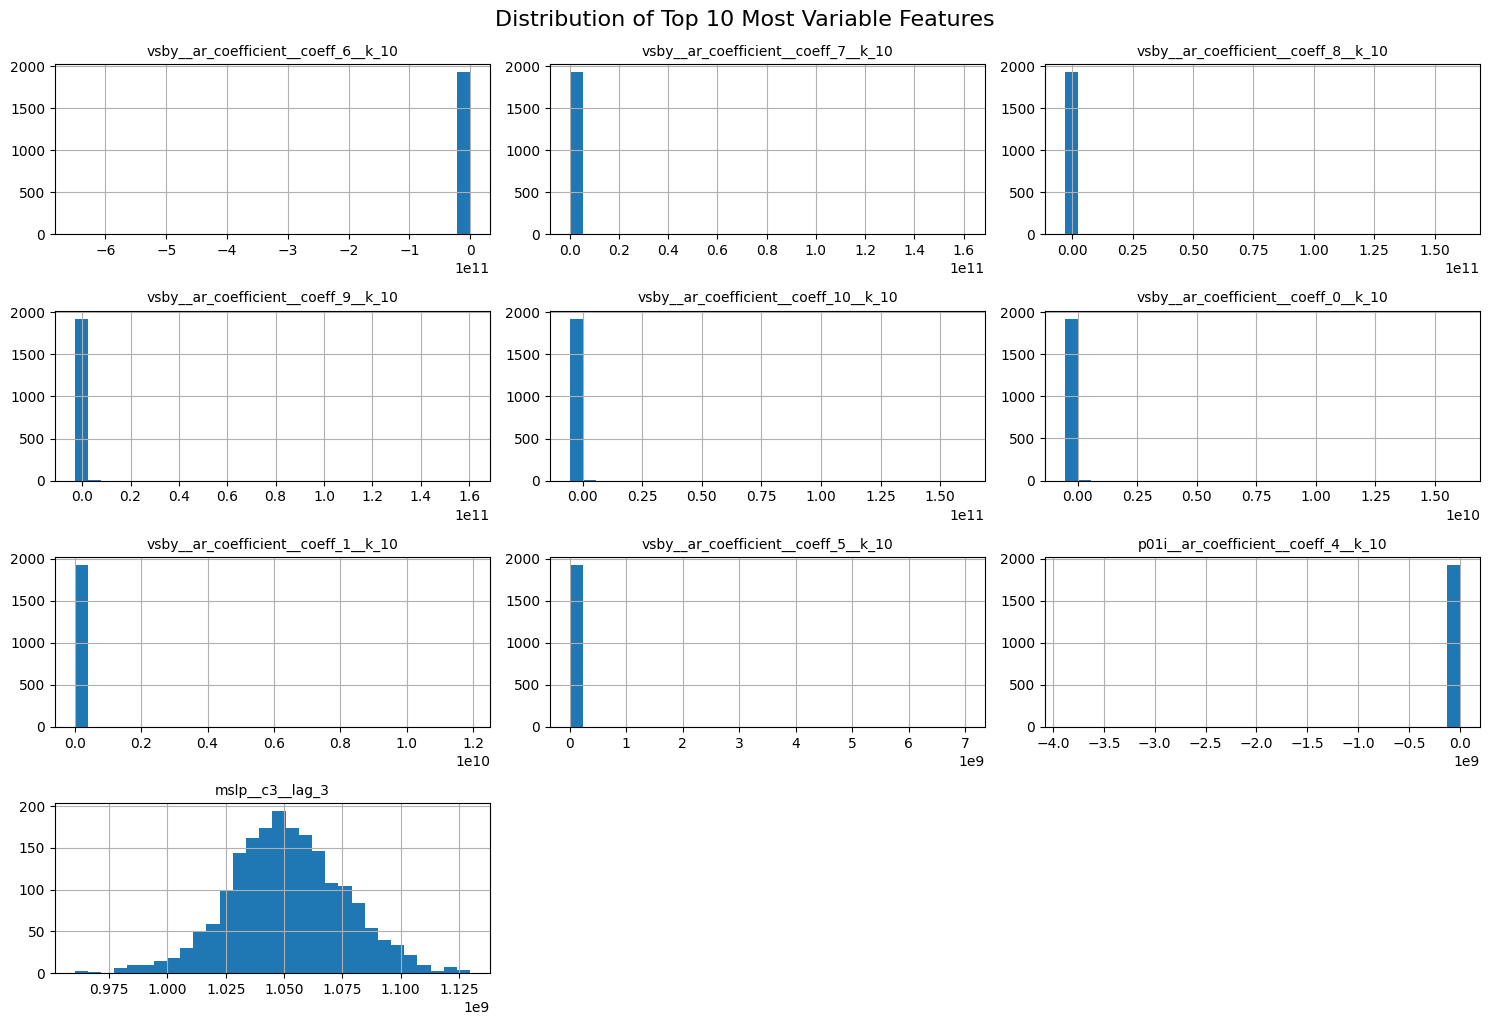

In [73]:
# Calculate variance for each feature and select the top 10 most variable ones
feature_variances = features_filtered.var().sort_values(ascending=False)
top_10_features = feature_variances.head(10).index.tolist()

# Plot the distributions of the top 10 features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_10_features):
    plt.subplot(4, 3, i + 1) # Adjust subplot grid as needed
    features_filtered[feature].hist(bins=30)
    plt.title(feature, fontsize=10)
    plt.xlabel('') # Remove x-label to avoid clutter
    plt.ylabel('') # Remove y-label
plt.tight_layout()
plt.suptitle('Distribution of Top 10 Most Variable Features', y=1.02, fontsize=16)
plt.show()


### Pairplot
To get a feel the dataset, I'll look at the first 15 features.

In [74]:
print(features_filtered.columns[:15])

Index(['tmpf__sum_values', 'tmpf__abs_energy', 'tmpf__minimum',
       'tmpf__benford_correlation', 'tmpf__root_mean_square',
       'tmpf__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_2__w_20__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_3__w_2__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_3__w_5__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_3__w_10__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_4__w_5__widths_(2, 5, 10, 20)',
       'tmpf__quantile__q_0.6', 'tmpf__quantile__q_0.4'],
      dtype='object')


In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the first 15 features from features_filtered
first_15_features = features_filtered.iloc[:, :15]

# Create the pairplot
sns.pairplot(first_15_features)
plt.suptitle('Pairplot of First 15 Filtered Features', y=1.02)
plt.show()


Output hidden; open in https://colab.research.google.com to view.

# Build a basic model

In [76]:
X = features_filtered
print(X.columns)
Y

Index(['tmpf__sum_values', 'tmpf__abs_energy', 'tmpf__minimum',
       'tmpf__benford_correlation', 'tmpf__root_mean_square',
       'tmpf__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_2__w_20__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_3__w_2__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)',
       'tmpf__cwt_coefficients__coeff_3__w_5__widths_(2, 5, 10, 20)',
       ...
       'tmpf__fft_coefficient__attr_"abs"__coeff_7',
       'drct__fft_coefficient__attr_"abs"__coeff_6',
       'drct__symmetry_looking__r_0.15000000000000002',
       'vsby__fft_coefficient__attr_"real"__coeff_8',
       'vsby__index_mass_quantile__q_0.1',
       'vsby__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4',
       'tmpf__ratio_beyond_r_sigma__r_0.5',
       'p01i__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2',
       'alti__number_peaks__n_3',
       'vsby__fft_coeffic

,Date,dwpf
0,2015-01-01,14.000
1,2015-01-02,23.000
2,2015-01-03,26.960
3,2015-01-04,38.480
4,2015-01-05,35.060
...,...,...
1923,2020-04-07,32.000
1924,2020-04-08,43.000
1925,2020-04-09,46.325
1926,2020-04-10,28.900


In [77]:
Y.index = Y['Date']
Y_dates = Y['Date']
del Y['Date']
Y = np.array(Y)

In [78]:
Y = pd.DataFrame(Y)
Y.index = Y_dates
Y.head()

,0
Date,
2015-01-01,14.00
2015-01-02,23.00
2015-01-03,26.96
2015-01-04,38.48
2015-01-05,35.06


## With a random holdout (dangerous for time series!)

In [79]:
from sklearn.model_selection import train_test_split

# Perform train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of Y_train: {Y_train.shape}")
print(f"Shape of Y_test: {Y_test.shape}")

Shape of X_train: (1542, 1920)
Shape of X_test: (386, 1920)
Shape of Y_train: (1542, 1)
Shape of Y_test: (386, 1)


In [80]:
from sklearn.tree import DecisionTreeRegressor

# Initialize a Decision Tree Regressor
dtr = DecisionTreeRegressor(random_state=42, min_samples_leaf=5)

# Fit the model to the training data
dtr.fit(X_train, Y_train)

print("Decision Tree Regressor fitted successfully!")

Decision Tree Regressor fitted successfully!


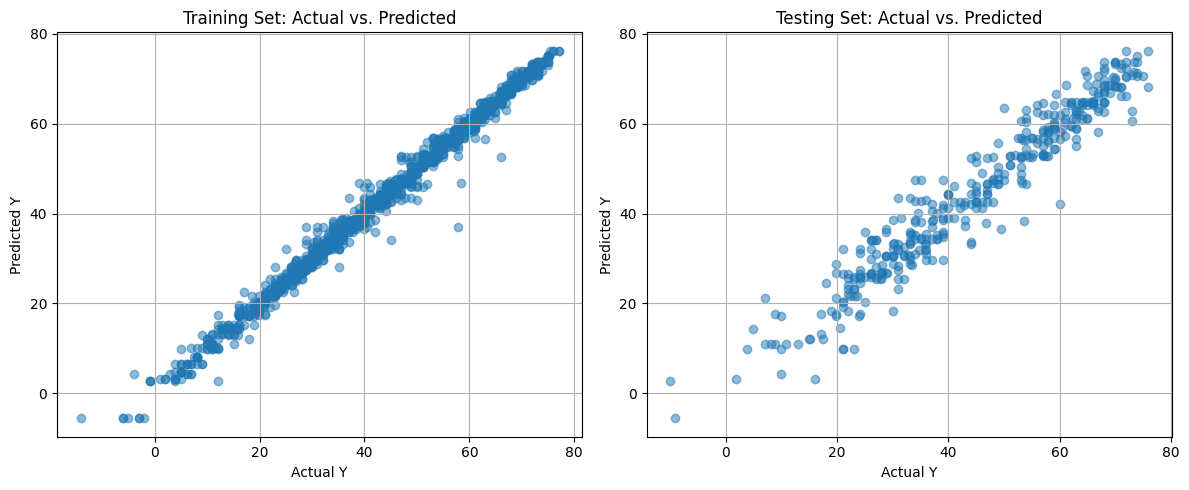

In [81]:
import matplotlib.pyplot as plt

# Make predictions on the training and testing sets
Y_train_pred = dtr.predict(X_train)
Y_test_pred = dtr.predict(X_test)

# Create subplots for better visualization
plt.figure(figsize=(12, 5))

# Scatter plot for Actual vs. Predicted (Training Set)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(Y_train, Y_train_pred, alpha=0.5)
plt.plot([min(Y_train), max(Y_train)], [min(Y_train), max(Y_train)], color='red', linestyle='--') # Ideal line
plt.title('Training Set: Actual vs. Predicted')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.grid(True)

# Scatter plot for Actual vs. Predicted (Testing Set)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(Y_test, Y_test_pred, alpha=0.5)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--') # Ideal line
plt.title('Testing Set: Actual vs. Predicted')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.grid(True)

plt.tight_layout()
plt.show()

In [82]:
from sklearn.metrics import r2_score, mean_absolute_error

# Calculate R2 and MAE for the training set
r2_train = r2_score(Y_train, Y_train_pred)
mae_train = mean_absolute_error(Y_train, Y_train_pred)

# Calculate R2 and MAE for the testing set
r2_test = r2_score(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)

print(f"Training Set R2: {r2_train:.4f}")
print(f"Training Set MAE: {mae_train:.4f}")
print(f"Testing Set R2: {r2_test:.4f}")
print(f"Testing Set MAE: {mae_test:.4f}")

Training Set R2: 0.9917
Training Set MAE: 1.0694
Testing Set R2: 0.9325
Testing Set MAE: 3.4706


### With last 20% holdout

In [83]:
# Calculate the split point for the last 20% as holdout
split_point = int(len(X) * 0.8)

# Split X and Y into training and testing sets
X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
Y_train = Y.iloc[:split_point]
Y_test = Y.iloc[split_point:]

print(f"Shape of X_train_ts: {X_train.shape}")
print(f"Shape of X_test_ts: {X_test.shape}")
print(f"Shape of Y_train_ts: {Y_train.shape}")
print(f"Shape of Y_test_ts: {Y_test.shape}")

Shape of X_train_ts: (1542, 1920)
Shape of X_test_ts: (386, 1920)
Shape of Y_train_ts: (1542, 1)
Shape of Y_test_ts: (386, 1)


In [84]:
from sklearn.tree import DecisionTreeRegressor

# Initialize a Decision Tree Regressor
dtr = DecisionTreeRegressor(random_state=42, min_samples_leaf=5)

# Fit the model to the training data
dtr.fit(X_train, Y_train)

print("Decision Tree Regressor fitted successfully!")

Decision Tree Regressor fitted successfully!


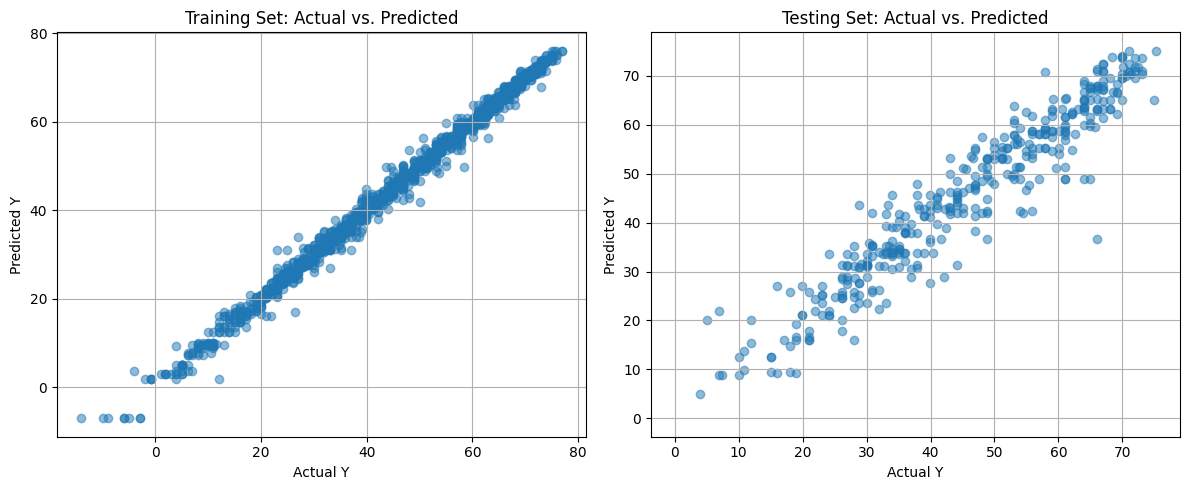

In [85]:
import matplotlib.pyplot as plt

# Make predictions on the training and testing sets
Y_train_pred = dtr.predict(X_train)
Y_test_pred = dtr.predict(X_test)

# Create subplots for better visualization
plt.figure(figsize=(12, 5))

# Scatter plot for Actual vs. Predicted (Training Set)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(Y_train, Y_train_pred, alpha=0.5)
plt.plot([min(Y_train), max(Y_train)], [min(Y_train), max(Y_train)], color='red', linestyle='--') # Ideal line
plt.title('Training Set: Actual vs. Predicted')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.grid(True)

# Scatter plot for Actual vs. Predicted (Testing Set)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(Y_test, Y_test_pred, alpha=0.5)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--') # Ideal line
plt.title('Testing Set: Actual vs. Predicted')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.grid(True)

plt.tight_layout()
plt.show()

In [86]:
from sklearn.metrics import r2_score, mean_absolute_error

# Calculate R2 and MAE for the training set
r2_train = r2_score(Y_train, Y_train_pred)
mae_train = mean_absolute_error(Y_train, Y_train_pred)

# Calculate R2 and MAE for the testing set
r2_test = r2_score(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)

print(f"Training Set R2: {r2_train:.4f}")
print(f"Training Set MAE: {mae_train:.4f}")
print(f"Testing Set R2: {r2_test:.4f}")
print(f"Testing Set MAE: {mae_test:.4f}")

Training Set R2: 0.9938
Training Set MAE: 0.9914
Testing Set R2: 0.9071
Testing Set MAE: 3.7605


### Time Series Plot

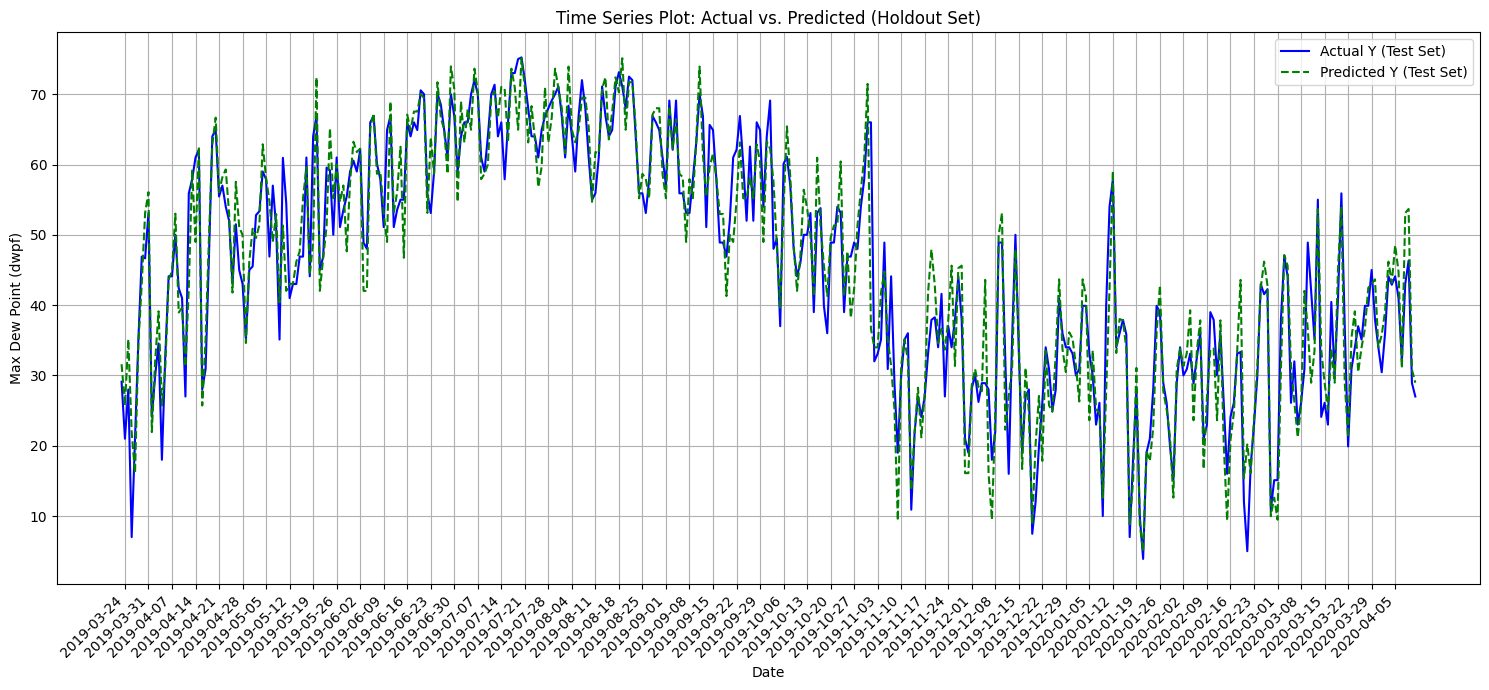

In [91]:
import matplotlib.pyplot as plt

# Ensure Y_test index is datetime for proper plotting and date range generation
Y_test.index = pd.to_datetime(Y_test.index)

# Ensure Y_test_pred is a Series for easier plotting with a time index
# It's a numpy array, so we'll convert it and assign the now-datetime index from Y_test
if isinstance(Y_test_pred, np.ndarray):
    Y_test_pred_series = pd.Series(Y_test_pred.flatten(), index=Y_test.index, name='Predicted')
else:
    Y_test_pred_series = Y_test_pred

plt.figure(figsize=(15, 7))
plt.plot(Y_test.index, Y_test, label='Actual Y (Test Set)', color='blue')
plt.plot(Y_test_pred_series.index, Y_test_pred_series, label='Predicted Y (Test Set)', color='green', linestyle='--')
plt.title('Time Series Plot: Actual vs. Predicted (Holdout Set)')
plt.xlabel('Date')
plt.ylabel('Max Dew Point (dwpf)')
plt.legend()
plt.grid(True)

# Generate weekly ticks for better spacing
min_date = Y_test.index.min()
max_date = Y_test.index.max()
weekly_ticks = pd.date_range(start=min_date, end=max_date, freq='W') # Use datetime objects directly
plt.xticks(ticks=weekly_ticks, rotation=45, ha='right') # Apply weekly ticks and rotate labels
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Analysis
The last 20% chunk holdout is worst - of course it is! Data leakage from the day before and after can inform the model of artifacts from the data... 3.73 MAE from last 20% holdout vs. 3.47 MAE from random 20% holdout. DONT LEAK!

# Anomaly Detection

Anomaly Threshold (99th percentile of absolute errors): 14.9516
Number of anomalies detected: 4


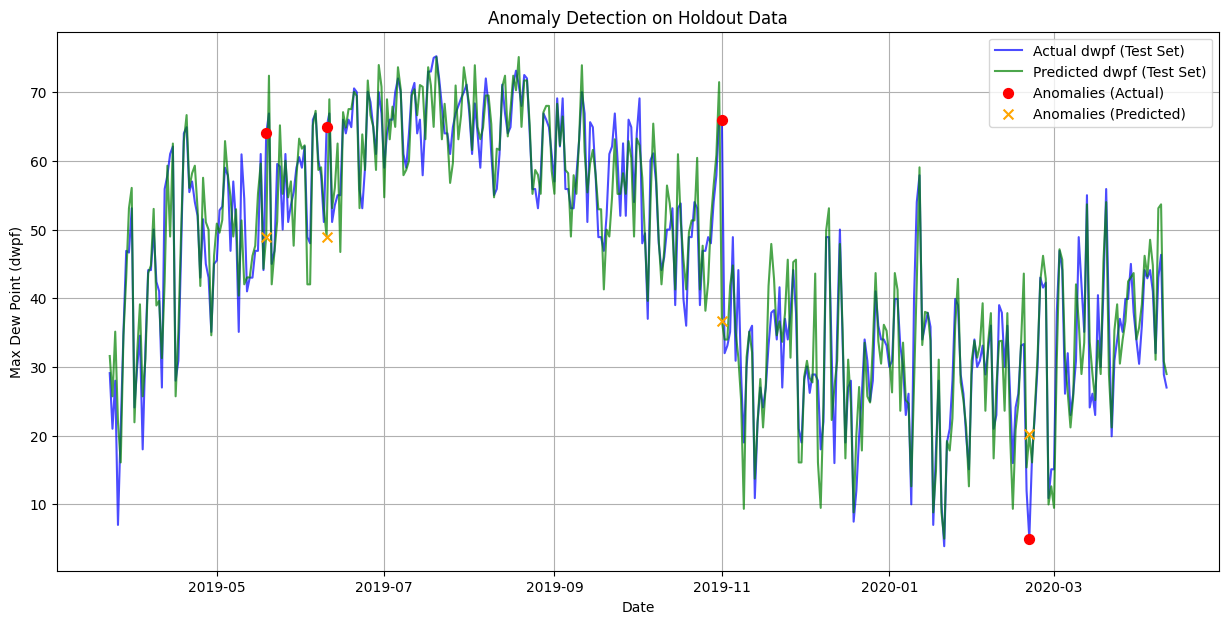

In [95]:
# Calculate residuals (prediction errors)
# Squeeze Y_test to convert the (386, 1) DataFrame to a (386,) Series for element-wise subtraction
residuals = Y_test.squeeze() - Y_test_pred
abs_residuals = np.abs(residuals)

# Define an anomaly threshold (e.g., 99th percentile of absolute residuals)
anomaly_threshold = np.percentile(abs_residuals, 99)

# Identify anomalies
anomalies = Y_test[abs_residuals > anomaly_threshold]
anomaly_preds = Y_test_pred[abs_residuals > anomaly_threshold]

print(f"Anomaly Threshold (99th percentile of absolute errors): {anomaly_threshold:.4f}")
print(f"Number of anomalies detected: {len(anomalies)}")

# Visualize the anomalies
plt.figure(figsize=(15, 7))
plt.plot(Y_test.index, Y_test, label='Actual dwpf (Test Set)', color='blue', alpha=0.7)
plt.plot(Y_test.index, Y_test_pred, label='Predicted dwpf (Test Set)', color='green', alpha=0.7)
plt.scatter(anomalies.index, anomalies, color='red', label='Anomalies (Actual)', s=50, zorder=5)
plt.scatter(anomalies.index, anomaly_preds, color='orange', label='Anomalies (Predicted)', s=50, zorder=5, marker='x')
plt.title('Anomaly Detection on Holdout Data')
plt.xlabel('Date')
plt.ylabel('Max Dew Point (dwpf)')
plt.legend()
plt.grid(True)
plt.show()